### Notebook
- **Name:** `cs_wind_rose.ipynb`
- **Created/updated:** 2026-02-27
- **Python:** 3.x

### Purpose
Download wind data and generate wind roses and related statistics.

### Inputs
Point location (lat/lon or UTM) and selected data source credentials (if needed).

### Outputs
Frequency tables and wind-rose PNG (and optional fitted distribution parameters).

### Dependencies
- (see imports below)

### Usage
Executed by the project pipeline (e.g., via Papermill) or run interactively in Jupyter.

### Notes
- Keep paths and parameters centralized in `config.toml` / `CONFIG_PATH` where applicable.


In [42]:
# Parameters (Papermill)
CONFIG_PATH = r"E:\mario\trabajos2\viesgo_edp_portugal_cic\estudios_microclimaticos\Corredoria_Grado_1_y_2\config.toml" # "config.toml" #"config.toml"
PROJECT_ROOT = r"E:\mario\python\criticalspam"

### Wind rose

Provide the point either as:
- geographic coordinates `(lat, lon)`, or
- UTM coordinates `(x, y)` (specifying EPSG or zone/hemisphere).

Download wind time series to build a wind rose from:
- **NASA POWER** (gridded, hourly at a point),
- **ERA5** (Copernicus/ECMWF via CDS API; gridded, hourly; requires CDS credentials),
- **AEMET OpenData** (nearest station: inventory + daily climatological values; not hourly).

Build and save:
- a frequency table, and
- a PNG image with the wind rose.

Methodological note: a “classic” wind rose uses wind direction sectors and wind speed bins; the chosen binning
must be reported when comparing roses across locations or datasets.


In [43]:
import sys
print(sys.version)
print(sys.executable)

3.12.7 (tags/v3.12.7:0b05ead, Oct  1 2024, 03:06:41) [MSC v.1941 64 bit (AMD64)]
c:\Python\Python312\python.exe


In [44]:
from __future__ import annotations

import re
from pathlib import Path
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from dataclasses import dataclass
import argparse
import math
import os
import tempfile
from datetime import date, datetime
from typing import Iterable, List, Optional, Sequence, Tuple
import numpy as np

from collections import namedtuple

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
from typing import Optional


# Para coordenadas
from pyproj import CRS, Transformer

# Para descargas
import requests

# Para ERA5
import xarray as xr

# Para plotting
import matplotlib.pyplot as plt

# Para fichero configuracion
import tomllib

# Estadística
from scipy.stats import weibull_min, kstest
from scipy.special import gamma

import papermill as pm
from pathlib import Path


In [45]:

# Ruta al directorio raíz del proyecto (sube 1 nivel desde notebooks/)
#ROOT = Path.cwd().resolve().parent

# Añade src/ al path de importación
SRC = Path(PROJECT_ROOT + r"\src") 
print(f"Adding to sys.path: {SRC}")


if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

# Ya puedes importar
from cs_utils import Config, join_base, load_config_toml

Adding to sys.path: E:\mario\python\criticalspam\src


In [46]:
# --- Entradas/salidas ---
# Línea Ribadeo-Barreiros
#config_toml_path = r"E:\mario\trabajos2\viesgo_edp_portugal_cic\estudios_microclimaticos\Ribadeo_Barreiros\config.toml"
# Línea Corredoria-Maruca (Corremar)
#config_toml_path = r"E:\mario\trabajos2\viesgo_edp_portugal_cic\estudios_microclimaticos\Corredoria_Maruca\config.toml"
# Línea Tabiella-Trasona
#config_toml_path = r"E:\mario\trabajos2\viesgo_edp_portugal_cic\estudios_microclimaticos\Tabiella_Trasona\config.toml"
# Línea Corredoria-Castiello
#config_toml_path = r"E:\mario\trabajos2\viesgo_edp_portugal_cic\estudios_microclimaticos\Corredoria_Castiello\config.toml"
# Línea Corredoria-Grado
#config_toml_path = r"E:\mario\trabajos2\viesgo_edp_portugal_cic\estudios_microclimaticos\Corredoria_Grado_1_y_2\config.toml"

#config_toml_path = CONFIG_PATH


#with open(Path(config_toml_path), "rb") as f:
#    config_toml_path = tomllib.load(f)

cfg = load_config_toml(CONFIG_PATH)

print("cs_wind_rose.ipynb")
print("Config path:", CONFIG_PATH)


cs_wind_rose.ipynb
Config path: E:\mario\trabajos2\viesgo_edp_portugal_cic\estudios_microclimaticos\Corredoria_Grado_1_y_2\config.toml


In [47]:
"""
Descarga de viento (WS/WD) para un punto y generación de rosa de vientos.
Fuentes soportadas:
  - NASA POWER (horario, point)
  - ERA5 (horario, U10/V10 -> WS/WD) via CDS API
  - AEMET OpenData (diario, estación climatológica más cercana)

Ejemplos:
  # 1) NASA POWER con lat/lon
  python wind_rose_fetch.py power --lat 43.4623 --lon -3.80998 --start 2023-01-01 --end 2023-12-31 --plot power.png --out power.csv

  # 2) NASA POWER con UTM (EPSG 25830 = ETRS89 / UTM 30N)
  python wind_rose_fetch.py power --utm-x 415000 --utm-y 4812000 --epsg 25830 --start 2023-01-01 --end 2023-12-31 --plot power.png

  # 3) ERA5 con lat/lon
  python wind_rose_fetch.py era5 --lat 43.4623 --lon -3.80998 --start 2023-01-01 --end 2023-03-31 --plot era5.png --out era5.csv

  # 4) AEMET diario (estación más cercana)
  export AEMET_API_KEY="TU_API_KEY"
  python wind_rose_fetch.py aemet --lat 43.4623 --lon -3.80998 --start 2023-01-01 --end 2023-12-31 --plot aemet.png --out aemet.csv
"""


'\nDescarga de viento (WS/WD) para un punto y generación de rosa de vientos.\nFuentes soportadas:\n  - NASA POWER (horario, point)\n  - ERA5 (horario, U10/V10 -> WS/WD) via CDS API\n  - AEMET OpenData (diario, estación climatológica más cercana)\n\nEjemplos:\n  # 1) NASA POWER con lat/lon\n  python wind_rose_fetch.py power --lat 43.4623 --lon -3.80998 --start 2023-01-01 --end 2023-12-31 --plot power.png --out power.csv\n\n  # 2) NASA POWER con UTM (EPSG 25830 = ETRS89 / UTM 30N)\n  python wind_rose_fetch.py power --utm-x 415000 --utm-y 4812000 --epsg 25830 --start 2023-01-01 --end 2023-12-31 --plot power.png\n\n  # 3) ERA5 con lat/lon\n  python wind_rose_fetch.py era5 --lat 43.4623 --lon -3.80998 --start 2023-01-01 --end 2023-03-31 --plot era5.png --out era5.csv\n\n  # 4) AEMET diario (estación más cercana)\n  export AEMET_API_KEY="TU_API_KEY"\n  python wind_rose_fetch.py aemet --lat 43.4623 --lon -3.80998 --start 2023-01-01 --end 2023-12-31 --plot aemet.png --out aemet.csv\n'

In [48]:

# -----------------------
# Utilidades de coordenadas
# -----------------------

@dataclass(frozen=True)
class PointLL:
    lat: float
    lon: float


def utm_to_latlon(x: float, y: float, epsg: Optional[int] = None,
                  zone: Optional[int] = None, hemisphere: Optional[str] = None) -> PointLL:
    """
    Convierte UTM (x,y) a lat/lon.

    Opción A (recomendada): pasar EPSG (p.ej. 25830 ETRS89 / UTM 30N, 32630 WGS84 / UTM 30N).
    Opción B: pasar zone y hemisphere ('N' o 'S') asumiendo WGS84 UTM (EPSG:326xx/327xx).
    """
    if epsg is None:
        if zone is None or hemisphere is None:
            raise ValueError("Para UTM debes indicar --epsg o bien (--utm-zone y --utm-hemisphere).")
        hem = hemisphere.upper()
        if hem not in ("N", "S"):
            raise ValueError("--utm-hemisphere debe ser 'N' o 'S'.")
        epsg = (32600 + zone) if hem == "N" else (32700 + zone)

    src = CRS.from_epsg(int(epsg))
    dst = CRS.from_epsg(4326)  # WGS84 lat/lon
    tr = Transformer.from_crs(src, dst, always_xy=True)
    lon, lat = tr.transform(x, y)
    return PointLL(lat=float(lat), lon=float(lon))


def resolve_point(args: argparse.Namespace) -> PointLL:
    if args.lat is not None and args.lon is not None:
        return PointLL(lat=float(args.lat), lon=float(args.lon))

    if args.utm_x is not None and args.utm_y is not None:
        return utm_to_latlon(
            x=float(args.utm_x),
            y=float(args.utm_y),
            epsg=args.epsg,
            zone=args.utm_zone,
            hemisphere=args.utm_hemisphere
        )

    raise ValueError("Debes indicar (--lat --lon) o bien (--utm-x --utm-y y --epsg/--utm-zone/--utm-hemisphere).")


# -----------------------
# Rosa de vientos (cálculo y plot)
# -----------------------

def compute_wind_rose_table(
    wd_deg: np.ndarray,
    ws: np.ndarray,
    n_dir: int = 16,
    speed_bins: Sequence[float] = (0, 2, 4, 6, 8, 10, 15, 20, np.inf),
) -> pd.DataFrame:
    """
    Devuelve una tabla (DataFrame) con frecuencias relativas por:
      - sector direccional (n_dir)
      - rango de velocidad (speed_bins)

    Convención: wd_deg en grados meteorológicos (0=N, 90=E, 180=S, 270=O), "de procedencia".
    """
    wd = np.asarray(wd_deg, dtype=float) % 360.0
    ws = np.asarray(ws, dtype=float)

    valid = np.isfinite(wd) & np.isfinite(ws)
    wd = wd[valid]
    ws = ws[valid]
    if wd.size == 0:
        raise ValueError("No hay datos válidos de WD/WS tras el filtrado.")

    # Sectores: 0..n_dir-1, centrados en N.
    sector_width = 360.0 / n_dir
    # Desplazamiento medio sector para asignación centrada:
    sector = np.floor(((wd + sector_width/2) % 360.0) / sector_width).astype(int)

    # Bins de velocidad
    bins = np.array(speed_bins, dtype=float)
    # Etiquetas legibles
    bin_labels = []
    for i in range(len(bins)-1):
        a, b = bins[i], bins[i+1]
        if np.isinf(b):
            bin_labels.append(f">={a:g}")
        else:
            bin_labels.append(f"[{a:g},{b:g})")

    ws_bin = np.digitize(ws, bins=bins, right=False) - 1
    ws_bin = np.clip(ws_bin, 0, len(bin_labels)-1)

    # Conteo
    counts = np.zeros((n_dir, len(bin_labels)), dtype=int)
    for s, b in zip(sector, ws_bin):
        counts[s, b] += 1

    freq = counts / counts.sum()  # frecuencias relativas
    df = pd.DataFrame(freq, columns=bin_labels)
    df.index.name = "sector"
    return df


def plot_wind_rose(
    table: pd.DataFrame,
    n_dir: int,
    title: str,
    out_png: Optional[str] = None,
    use_tex: bool = True,
    font_size: int = 12,
    title_size: int = 12,
    legend_size: int = 12,
    tick_size: int = 12,
):
    """
    Plot polar (stacked bars) using relative frequency table.
    LaTeX rendering and font size control included.
    """

    # =========================
    # Configuración tipográfica
    # =========================
    mpl.rcParams.update({
        "text.usetex": use_tex,
        "font.size": font_size,
        "axes.titlesize": title_size,
        "xtick.labelsize": tick_size,
        "ytick.labelsize": tick_size,
        "legend.fontsize": legend_size,
    })

    # =========================
    # Geometría
    # =========================
    sector_width = 2 * np.pi / n_dir
    theta = np.arange(n_dir) * sector_width

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, polar=True)
    
      # Fondo
    fig.patch.set_facecolor("white")      # exterior (ticks, labels, márgenes)
    ax.set_facecolor("#ffe5e0")           # interior (salmón claro)

    # =========================
    # Barras apiladas
    # =========================
    bottom = np.zeros(n_dir)
    for col in table.columns:
        values = table[col].values
        ax.bar(
            theta,
            values,
            width=sector_width,
            bottom=bottom,
            align="edge",
            label=col  # importante para legend
        )
        bottom += values

    # =========================
    # Configuración polar
    # =========================
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    ax.set_title(title, fontsize=title_size)

    # =========================
    # Etiquetas de sectores
    # =========================
    labels = ["N", "NNE", "NE", "ENE",
              "E", "ESE", "SE", "SSE",
              "S", "SSW", "SW", "WSW",
              "W", "WNW", "NW", "NNW"]

    if n_dir == 16:
        ax.set_xticks(theta + sector_width/2)
        ax.set_xticklabels(labels, fontsize=tick_size)
    else:
        ax.set_xticks(theta + sector_width/2)

    # =========================
    # Leyenda
    # =========================
    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.15, 1.05),
        fontsize=legend_size,
        frameon=True
    )

    # =========================
    # Ajuste ticks radiales
    # =========================
    ax.tick_params(axis="y", labelsize=tick_size)

    # =========================
    # Guardado
    # =========================
    fig.tight_layout()
    if out_png:
        fig.savefig(out_png, dpi=200, bbox_inches="tight")

    return fig, ax


#### NASA


In [49]:
# -----------------------
# NASA POWER (horario)
# -----------------------

def fetch_power_hourly(lat: float, lon: float, start: date, end: date) -> pd.DataFrame:
    """
    Descarga WS10M y WD10M (horario) desde NASA POWER para un punto.
    """
    # Documentación: microservicio hourly / point.
    url = (
        "https://power.larc.nasa.gov/api/temporal/hourly/point"
        f"?parameters=WS10M,WD10M"
        f"&community=SB"
        f"&longitude={lon}&latitude={lat}"
        f"&start={start.strftime('%Y%m%d')}&end={end.strftime('%Y%m%d')}"
        f"&format=JSON&time-standard=UTC"
    )
    r = requests.get(url, timeout=120)
    r.raise_for_status()
    js = r.json()
    params = js["properties"]["parameter"]

    df = pd.DataFrame({
        "WS10M": pd.Series(params["WS10M"]),
        "WD10M": pd.Series(params["WD10M"]),
    })
    df.index = pd.to_datetime(df.index, format="%Y%m%d%H")
    df.index.name = "time_utc"
    df = df.replace(-999, np.nan).dropna()
    return df



#### ERA5


In [50]:
# -----------------------
# ERA5 (CDS API): U10/V10 -> WS/WD
# -----------------------

def uv_to_ws_wd(u: np.ndarray, v: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Convierte componentes (u,v) a:
      - WS = sqrt(u^2 + v^2)
      - WD meteorológica (dirección "de procedencia"): atan2(-u, -v)
    """
    ws = np.sqrt(u*u + v*v)
    wd = (np.degrees(np.arctan2(-u, -v)) + 360.0) % 360.0
    return ws, wd


def month_range(start: date, end: date) -> List[Tuple[int, int]]:
    months = []
    y, m = start.year, start.month
    while (y, m) <= (end.year, end.month):
        months.append((y, m))
        m += 1
        if m == 13:
            m = 1
            y += 1
    return months


def fetch_era5_hourly_point(lat: float, lon: float, start: date, end: date) -> pd.DataFrame:
    """
    Descarga ERA5 horario (u10, v10) para una pequeña caja alrededor del punto y
    luego interpola bilinealmente al (lat,lon).
    Requiere configurar CDS API (~/.cdsapirc) y tener permisos.
    """
    try:
        import cdsapi
    except ImportError as e:
        raise ImportError("Instala cdsapi: pip install cdsapi") from e

    c = cdsapi.Client()

    # Caja pequeña para interpolación (0.25º suele coincidir con grid ERA5)
    d = 0.125
    area = [lat + d, lon - d, lat - d, lon + d]  # N, W, S, E

    frames = []
    with tempfile.TemporaryDirectory() as td:
        for (yy, mm) in month_range(start, end):
            target = os.path.join(td, f"era5_u10v10_{yy:04d}{mm:02d}.nc")

            days_in_month = pd.Period(f"{yy:04d}-{mm:02d}").days_in_month
            days = [f"{d:02d}" for d in range(1, days_in_month + 1)]
            times = [f"{h:02d}:00" for h in range(0, 24)]

            # Petición ERA5 single-levels
            c.retrieve(
                "reanalysis-era5-single-levels",
                {
                    "product_type": "reanalysis",
                    "variable": ["10m_u_component_of_wind", "10m_v_component_of_wind"],
                    "year": f"{yy:04d}",
                    "month": f"{mm:02d}",
                    "day": days,
                    "time": times,
                    "area": area,
                    "format": "netcdf",
                },
                target
            )

            ds = xr.open_dataset(target)

            # Interpolación bilineal al punto (lat, lon)
            # Nota: en ERA5 suele ser coords: latitude, longitude.
            dsi = ds.interp(latitude=lat, longitude=lon)

            u10 = dsi["u10"].values
            v10 = dsi["v10"].values
            ws, wd = uv_to_ws_wd(u10, v10)

            t = pd.to_datetime(dsi["time"].values)
            df = pd.DataFrame({"WS10M": ws, "WD10M": wd}, index=t)
            df.index.name = "time_utc"
            frames.append(df)

        out = pd.concat(frames).sort_index()
        out = out.loc[(out.index.date >= start) & (out.index.date <= end)]
        out = out.replace([np.inf, -np.inf], np.nan).dropna()
        return out


#### AEMET OpenData


In [51]:
# -----------------------
# AEMET OpenData (diario): inventario + estación más cercana + serie diaria
# -----------------------

AEMET_BASE = "https://opendata.aemet.es/opendata/api"


def aemet_get_hateoas(path: str, api_key: str) -> object:
    """
    Llama a un endpoint AEMET OpenData (HATEOAS) y luego descarga el recurso indicado en el campo 'datos'.
    """
    url = f"{AEMET_BASE}{path}"
    r = requests.get(url, params={"api_key": api_key}, timeout=120)
    r.raise_for_status()
    js = r.json()
    datos_url = js.get("datos")
    if not datos_url:
        raise RuntimeError(f"Respuesta AEMET sin campo 'datos'. Respuesta: {js}")
    r2 = requests.get(datos_url, timeout=120)
    r2.raise_for_status()
    return r2.json()


def parse_aemet_coord(coord: object) -> float:
    """
    Convierte coordenadas AEMET (frecuentes en formato DDMMSS[N/S] / DDDMMSS[E/W]) a grados decimales.
    También acepta floats/strings decimales.
    """
    if coord is None:
        raise ValueError("Coordenada vacía.")
    if isinstance(coord, (int, float)):
        return float(coord)

    s = str(coord).strip()
    # Caso decimal con coma
    s = s.replace(",", ".")
    # Caso DMS con hemisferio final
    m = re.fullmatch(r"(\d{6,7})([NSEW])", s.upper())
    if m:
        digits, hemi = m.group(1), m.group(2)
        if len(digits) == 6:  # lat: DDMMSS
            dd = int(digits[0:2]); mm = int(digits[2:4]); ss = int(digits[4:6])
        else:  # lon: DDDMMSS
            dd = int(digits[0:3]); mm = int(digits[3:5]); ss = int(digits[5:7])
        val = dd + mm/60.0 + ss/3600.0
        if hemi in ("S", "W"):
            val = -val
        return float(val)

    # Fallback: decimal
    return float(s)


def haversine_km(lat1, lon1, lat2, lon2) -> float:
    R = 6371.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dl = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dl/2)**2
    return 2 * R * math.asin(math.sqrt(a))


def aemet_find_nearest_station(lat: float, lon: float, api_key: str) -> Tuple[str, float]:
    """
    Usa el inventario de estaciones climatológicas y devuelve:
      - indicativo/idema de la estación más cercana
      - distancia (km)
    """
    inv = aemet_get_hateoas("/valores/climatologicos/inventarioestaciones/todasestaciones/", api_key)

    best_id = None
    best_d = float("inf")

    for st in inv:
        try:
            st_lat = parse_aemet_coord(st.get("latitud"))
            st_lon = parse_aemet_coord(st.get("longitud"))
            d = haversine_km(lat, lon, st_lat, st_lon)
            if d < best_d:
                best_d = d
                # campo típico: 'indicativo' (idema)
                best_id = st.get("indicativo") or st.get("idema") or st.get("id")  # defensivo
        except Exception:
            continue

    if not best_id:
        raise RuntimeError("No se pudo determinar una estación AEMET cercana a partir del inventario.")
    return str(best_id), float(best_d)


def aemet_format_utc(dt: date) -> str:
    # Formato que aparece en ejemplos oficiales: YYYY-MM-DDTHH:MM:SSUTC
    return f"{dt.isoformat()}T00:00:00UTC"


def fetch_aemet_daily_station(lat: float, lon: float, start: date, end: date, api_key: str,
                             dir_scale: str = "auto") -> pd.DataFrame:
    """
    Descarga valores climatológicos diarios para la estación climatológica más cercana.

    Campos de interés esperables:
      - 'velmedia' (velocidad media)
      - 'dir' (dirección)
    Se devuelven como strings con coma decimal con frecuencia.

    dir_scale:
      - 'auto': si max(dir)<=36, multiplica por 10; si no, deja igual.
      - '1' o '10': fuerza escala.
    """
    station, dist_km = aemet_find_nearest_station(lat, lon, api_key)
    path = (
        f"/valores/climatologicos/diarios/datos/fechaini/{aemet_format_utc(start)}"
        f"/fechafin/{aemet_format_utc(end)}/estacion/{station}"
    )
    data = aemet_get_hateoas(path, api_key)

    df = pd.DataFrame(data)

    # Normalización numérica (coma decimal -> punto)
    def to_float(series: pd.Series) -> pd.Series:
        return pd.to_numeric(series.astype(str).str.replace(",", ".", regex=False), errors="coerce")

    ws = to_float(df.get("velmedia", pd.Series(dtype=str)))
    wd = to_float(df.get("dir", pd.Series(dtype=str)))

    # Escala direccional (defensivo)
    wd_clean = wd.dropna()
    scale = 1.0
    if dir_scale == "auto":
        if not wd_clean.empty and wd_clean.max() <= 36.0:
            scale = 10.0
    else:
        scale = float(dir_scale)

    wd = wd * scale

    out = pd.DataFrame({"WS10M": ws, "WD10M": wd})
    out.index = pd.to_datetime(df["fecha"], errors="coerce")
    out.index.name = "date"
    out = out.dropna()

    # Metadato útil:
    out.attrs["aemet_station"] = station
    out.attrs["aemet_station_distance_km"] = dist_km
    return out

In [52]:
# -----------------------
# CLI 
# -----------------------

def parse_date(s: str) -> date:
    return datetime.strptime(s, "%Y-%m-%d").date()

In [53]:

def parse_date_str(s: str):
    """
    parse_date_str.

    Notes
    -----
    Auto-generated docstring. Please refine parameter/return descriptions if needed.
    """
    return datetime.strptime(s, "%Y-%m-%d").date()

def load_config_toml(path: str) -> dict:
    with open(path, "rb") as f:
        cfg = tomllib.load(f)
    return cfg

def parse_bins(bins_list):
    """
    parse_bins.

    Notes
    -----
    Auto-generated docstring. Please refine parameter/return descriptions if needed.
    """
    bins = []
    for x in bins_list:
        if isinstance(x, str) and x.strip().lower() == "inf":
            bins.append(np.inf)
        else:
            bins.append(float(x))
    return bins

def resolve_point_from_cfg(cfg: dict):
    """
    resolve_point_from_cfg.

    Notes
    -----
    Auto-generated docstring. Please refine parameter/return descriptions if needed.
    """
    loc = cfg.get("location", {})
    lat = loc.get("lat", None)
    lon = loc.get("lon", None)
    utm_x = loc.get("utm_x", None)
    utm_y = loc.get("utm_y", None)
    epsg = loc.get("epsg", 25830)  # por defecto ETRS89/UTM30N

    # Prioridad: si vienen utm_x/utm_y, usar UTM
    if utm_x is not None and utm_y is not None:
        pt = utm_to_latlon(float(utm_x), float(utm_y), epsg=int(epsg))
        return pt

    # Si no, usar lat/lon
    if lat is not None and lon is not None:
        return PointLL(lat=float(lat), lon=float(lon))

    raise ValueError("Config inválida: define (lat,lon) o bien (utm_x,utm_y[,epsg]).")

In [54]:
def join_base(base: str | Path, p: str | Path) -> Path:
    base = Path(base)
    p = Path(p)
    return p if p.is_absolute() else (base / p)


In [55]:
# config_toml_path = CONFIG_PATH
# cfg = load_config_toml(config_toml_path)

source = cfg.weather_source    
if source not in ("power", "era5", "aemet"):
    raise ValueError("Config inválida: [source].name debe ser 'power', 'era5' o 'aemet'.")

start = parse_date_str( cfg.time_start) #(cfg["time"]["start"])
end   = parse_date_str( cfg.time_end) #(cfg["time"]["end"])
if start > end:
    raise ValueError("Config inválida: time.start debe ser <= time.end.")

In [56]:


Point = namedtuple("Point", ["lat", "lon"])

#pt = Point(lat=43.4623, lon=-3.8099)
pt = Point(lat=cfg.lat, lon=cfg.lon)  # resolve_point_from_cfg(cfg)

n_dir = cfg.wr_n_dir 
bins  = [0,2,4,6,8,10,15,20,"inf"] # parse_bins(cfg.get("windrose", {}).get("bins", [0,2,4,6,8,10,15,20,"inf"]))


base = cfg.general_path #get("paths", {}).get("general_path", None)

out_csv  = cfg.wr_csv # join_base( base, cfg.get("path", {}).get("wr_csv", None))
out_plot = cfg.wr_plot # join_base( base, cfg.get("path", {}).get("wr_plot", None))
title_in = cfg.wr_title

# Normaliza “no guardar”
out_csv  = None if (out_csv  is None or str(out_csv).strip() == "") else str(out_csv)
out_plot = None if (out_plot is None or str(out_plot).strip() == "") else str(out_plot)

print("SOURCE:", source)
print("POINT (lat,lon):", pt)
print("DATE:", start, "->", end)
print("n_dir:", n_dir, "bins:", bins)
print("out_csv:", out_csv)
print("out_plot:", out_plot)


SOURCE: power
POINT (lat,lon): Point(lat=43.4623, lon=-3.80998)
DATE: 2023-01-01 -> 2023-12-31
n_dir: 16 bins: [0, 2, 4, 6, 8, 10, 15, 20, 'inf']
out_csv: E:\mario\trabajos2\viesgo_edp_portugal_cic\estudios_microclimaticos\Corredoria_Grado_1_y_2\WR\Corredoria_Grado_wind_power.csv
out_plot: E:\mario\trabajos2\viesgo_edp_portugal_cic\estudios_microclimaticos\Corredoria_Grado_1_y_2\WR\Corredoria_Grado_wind_power.png


,WS10M,WD10M
time_utc,,
2023-01-01 00:00:00,6.63,196.0
2023-01-01 01:00:00,6.24,196.1
2023-01-01 02:00:00,6.03,194.9
2023-01-01 03:00:00,6.05,193.1
2023-01-01 04:00:00,5.94,189.5


Rosa de Viento @ (43.46230, -3.80998) — NASA
N muestras: 8760


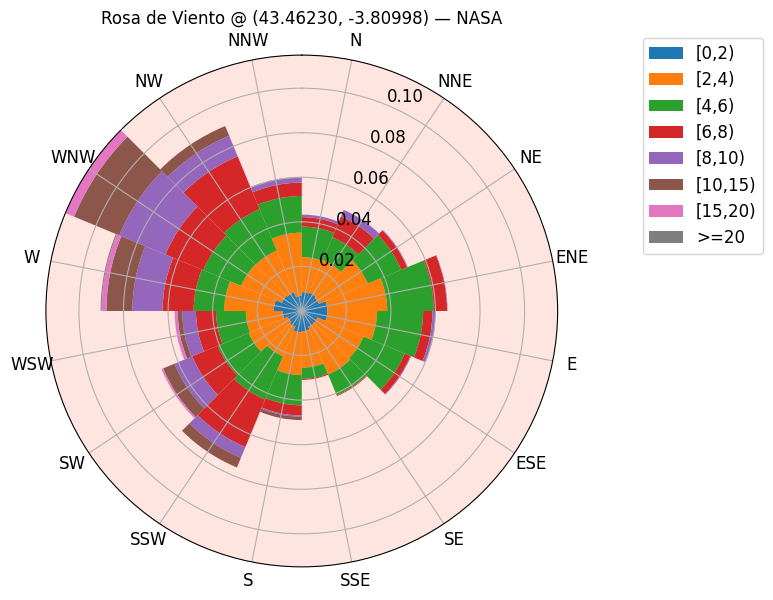

In [57]:


if source == "power":
    df = fetch_power_hourly(pt.lat, pt.lon, start, end)
    src_label = "NASA"

elif source == "era5":
    df = fetch_era5_hourly_point(pt.lat, pt.lon, start, end)
    src_label = "ERA5"

elif source == "aemet":
    aemet_cfg = cfg.get("aemet", {})
    key = (aemet_cfg.get("api_key", "") or "").strip() or os.getenv("AEMET_API_KEY")
    if not key:
        raise RuntimeError("Falta API key AEMET. Ponla en [aemet].api_key o en la variable de entorno AEMET_API_KEY.")

    dir_scale = str(aemet_cfg.get("dir_scale", "auto")).strip().lower()
    df = fetch_aemet_daily_station(pt.lat, pt.lon, start, end, key, dir_scale=dir_scale)

    st = df.attrs.get("aemet_station", "?")
    dk = df.attrs.get("aemet_station_distance_km", None)
    extra = f", station={st}"
    if dk is not None:
        extra += f" ({dk:.1f} km)"
    src_label = f"AEMET OpenData" # (daily{extra})"

else:
    raise RuntimeError("Fuente no soportada (esto no debería ocurrir si validaste config).")

# Guardar CSV si procede
if out_csv:
    df.to_csv(out_csv, index=True)

# Calcular tabla de rosa
table = compute_wind_rose_table(
    wd_deg=df["WD10M"].values,
    ws=df["WS10M"].values,
    n_dir=n_dir,
    speed_bins=bins,
)

# Título
title = title_in.strip() or f"Rosa de Viento @ ({pt.lat:.5f}, {pt.lon:.5f}) — {src_label}"

# Plot si procede
if out_plot:
    plot_wind_rose(table, n_dir=n_dir, title=title, out_png=out_plot, use_tex=False)

display(df.head())
print(title)
print("N muestras:", len(df))


In [58]:
out_plot

'E:\\mario\\trabajos2\\viesgo_edp_portugal_cic\\estudios_microclimaticos\\Corredoria_Grado_1_y_2\\WR\\Corredoria_Grado_wind_power.png'

#### Weibull (MLE)


In [59]:


def fit_weibull_2p(ws: np.ndarray, drop_zeros: bool = True, eps: float = 1e-6):
    """
    Ajuste Weibull 2-parámetros (loc=0) por máxima verosimilitud.
    
    Parámetros
    ----------
    ws : array
        Velocidades de viento (m/s).
    drop_zeros : bool
        Si True, elimina v<=0 (recomendado para estabilidad cuando hay muchas calmas).
        Si False, sustituye v<=0 por eps.
    eps : float
        Sustituto mínimo para v<=0 si drop_zeros=False.

    Returns
    -------
    dict con k, c, estadísticas y test KS.
    """
    v = np.asarray(ws, dtype=float)
    v = v[np.isfinite(v)]
    if drop_zeros:
        v = v[v > 0.0]
    else:
        v = np.where(v > 0.0, v, eps)

    if v.size < 20:
        raise ValueError("Muestras insuficientes para ajustar Weibull con robustez (se recomiendan >= 20).")

    # Ajuste MLE: fijamos loc=0 para Weibull 2p
    k, loc, c = weibull_min.fit(v, floc=0.0)

    # Estadísticos teóricos de Weibull( k, c )
    mean = c * gamma(1.0 + 1.0/k)
    var  = c**2 * (gamma(1.0 + 2.0/k) - (gamma(1.0 + 1.0/k))**2)
    std  = np.sqrt(var)

    # Percentiles teóricos (ejemplo)
    p50 = weibull_min.ppf(0.50, k, loc=0.0, scale=c)
    p90 = weibull_min.ppf(0.90, k, loc=0.0, scale=c)

    # Contraste KS (orientativo; estricto requeriría corrección por parámetros estimados)
    ks = kstest(v, lambda x: weibull_min.cdf(x, k, loc=0.0, scale=c))

    return {
        "k": float(k),
        "c": float(c),
        "mean": float(mean),
        "std": float(std),
        "p50": float(p50),
        "p90": float(p90),
        "n": int(v.size),
        "ks_stat": float(ks.statistic),
        "ks_pvalue": float(ks.pvalue),
    }




In [60]:
# Uso con tu DataFrame df
res = fit_weibull_2p(df["WS10M"].values, drop_zeros=True)

res

{'k': 1.7109668301667402,
 'c': 5.415124021616739,
 'mean': 4.829533520200269,
 'std': 2.907134884731926,
 'p50': 4.370956475776322,
 'p90': 8.81679517650399,
 'n': 8760,
 'ks_stat': 0.040900037178766224,
 'ks_pvalue': 3.6024984914755667e-13}

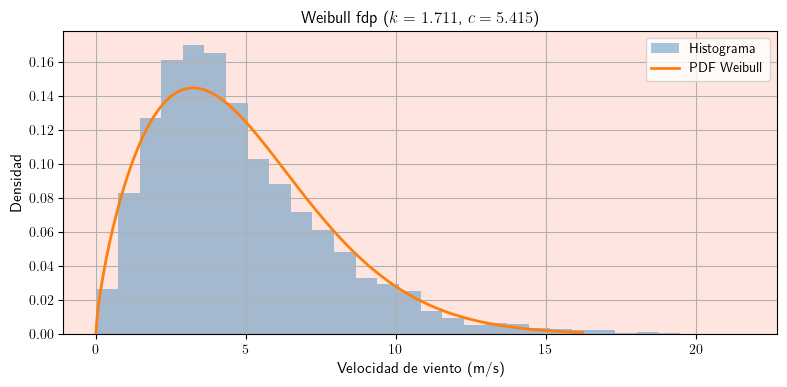

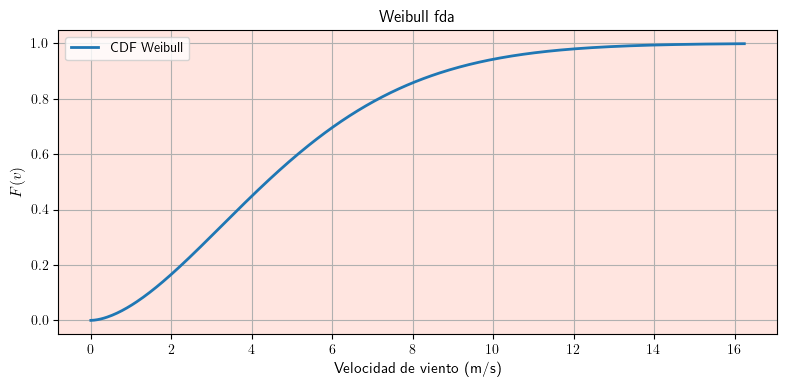

(<Figure size 800x400 with 1 Axes>,
 <Axes: title={'center': 'Weibull fdp ($k=1.711$, $c=5.415$)'}, xlabel='Velocidad de viento (m/s)', ylabel='Densidad'>,
 <Figure size 800x400 with 1 Axes>,
 <Axes: title={'center': 'Weibull fda'}, xlabel='Velocidad de viento (m/s)', ylabel='$F(v)$'>)

In [61]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import weibull_min

def plot_weibull_fit(
    ws: np.ndarray,
    k: float,
    c: float,
    bins: int = 30,
    use_tex: bool = True,
    font_size: int = 11,
    title_size: int = 12,
    label_size: int = 11,
    tick_size: int = 10,
    legend_size: int = 10,
):
    """
    Plot histogram + Weibull PDF and Weibull CDF with optional LaTeX text rendering
    and explicit font-size control.
    """
    mpl.rcParams.update({
        "text.usetex": use_tex,
        "font.size": font_size,
        "axes.titlesize": title_size,
        "axes.labelsize": label_size,
        "xtick.labelsize": tick_size,
        "ytick.labelsize": tick_size,
        "legend.fontsize": legend_size,
    })

    v = np.asarray(ws, dtype=float)
    v = v[np.isfinite(v)]
    v = v[v > 0.0]

    x = np.linspace(0, np.percentile(v, 99.5), 400)
    pdf = weibull_min.pdf(x, k, loc=0.0, scale=c)
    cdf = weibull_min.cdf(x, k, loc=0.0, scale=c)

    # =========================
    # Histograma + PDF
    # =========================
    fig1, ax1 = plt.subplots(figsize=(8, 4))
    ax1.hist(v, bins=bins, density=True, alpha=0.4, label=r"Histograma")
    ax1.plot(x, pdf, linewidth=2, label=r"PDF Weibull")
    
      # Fondo
    fig1.patch.set_facecolor("white")      # exterior (ticks, labels, márgenes)
    ax1.set_facecolor("#ffe5e0")           # interior (salmón claro)
    

    ax1.set_title(r"Weibull fdp ($k={:.3f}$, $c={:.3f}$)".format(k, c), fontsize=title_size)
    ax1.set_xlabel(r"Velocidad de viento (m/s)", fontsize=label_size)
    ax1.set_ylabel(r"Densidad", fontsize=label_size)
    ax1.tick_params(axis="both", labelsize=tick_size)
    ax1.grid(True)
    ax1.legend(fontsize=legend_size)
    fig1.tight_layout()
    plt.show()

    # =========================
    # CDF
    # =========================
    fig2, ax2 = plt.subplots(figsize=(8, 4))
    
      # Fondo
    fig2.patch.set_facecolor("white")      # exterior (ticks, labels, márgenes)
    ax2.set_facecolor("#ffe5e0")           # interior (salmón claro)
    
    
    ax2.plot(x, cdf, linewidth=2, label=r"CDF Weibull")

    ax2.set_title(r"Weibull fda", fontsize=title_size)
    ax2.set_xlabel(r"Velocidad de viento (m/s)", fontsize=label_size)
    ax2.set_ylabel(r"$F(v)$", fontsize=label_size)
    ax2.tick_params(axis="both", labelsize=tick_size)
    ax2.grid(True)
    ax2.legend(fontsize=legend_size)
    fig2.tight_layout()
    plt.show()

    return fig1, ax1, fig2, ax2




plot_weibull_fit(df["WS10M"].values, res["k"], res["c"])


#### CLI entry point (script-style)

The following snippet shows the command-line interface structure used when the notebook is exported as a script:

```python
def main():
    p = argparse.ArgumentParser(description="Download wind data and generate a wind rose.")
    sub = p.add_subparsers(dest="source", required=True)
    ...
```
